# MMAE 350 Companion Notebook  
## 2D Heat Conduction on a Rectangular Plate with Dirichlet Boundary Conditions

This notebook accompanies the lecture on **2D heat conduction** and the **five-point stencil**.

We will solve the steady-state problem

\begin{equation}
\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0
\end{equation}

on a rectangular plate with prescribed temperatures on all four edges.

We will:
1. build the grid,
2. impose Dirichlet boundary conditions,
3. solve the discrete Laplace equation with **Gauss--Seidel iteration**, and
4. visualize the temperature field.

## Problem setup

Consider a square plate with

\begin{equation}
0 \le x \le L_x, \qquad 0 \le y \le L_y
\end{equation}

with boundary conditions

\begin{equation}
T(0,y)=0, \qquad T(L_x,y)=100,
\end{equation}
\begin{equation}
T(x,0)=0, \qquad T(x,L_y)=0.
\end{equation}

So the **left, top, and bottom edges are cold**, and the **right edge is hot**.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# -----------------------------
# Physical / geometric settings
# -----------------------------
Lx = 1.0
Ly = 1.0

Nx = 41          # number of grid points in x
Ny = 41          # number of grid points in y

x = np.linspace(0.0, Lx, Nx)
y = np.linspace(0.0, Ly, Ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

print(f"Nx = {Nx}, Ny = {Ny}")
print(f"dx = {dx:.5f}, dy = {dy:.5f}")

Nx = 41, Ny = 41
dx = 0.02500, dy = 0.02500


## Initialize the temperature array

We store the nodal temperatures in a 2D array `T[j, i]`, where:
- `i` is the x-index,
- `j` is the y-index.

That means:
- `T[:, 0]` is the left boundary,
- `T[:, -1]` is the right boundary,
- `T[0, :]` is the bottom boundary,
- `T[-1, :]` is the top boundary.

In [12]:
# -----------------------------
# Temperature array
# -----------------------------
T = np.zeros((Ny, Nx))

# Dirichlet boundary conditions
T[:, 0]  = 0.0      # left
T[:, -1] = 100.0    # right
T[0, :]  = 0.0      # bottom
T[-1, :] = 0.0      # top

dfT = pd.DataFrame(T)
dfT

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


## Visualize the initial guess

The interior starts at zero, and the boundary values are imposed directly.

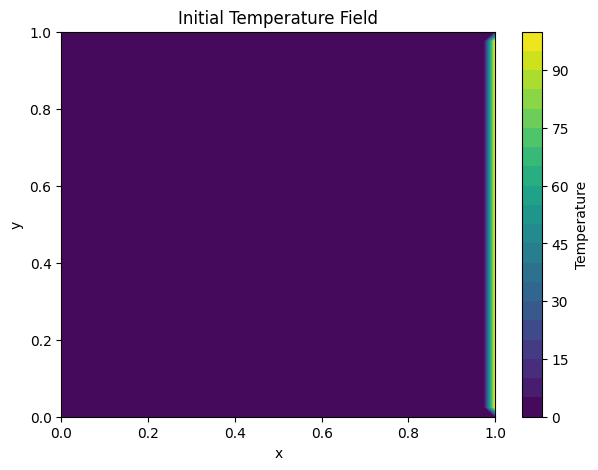

In [14]:
plt.figure(figsize=(7, 5))
plt.contourf(x, y, T, levels=20)
plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Initial Temperature Field")
plt.show()

## Discrete equation at an interior node

For a uniform square grid with `dx = dy = h`, the steady Laplace equation becomes
\begin{equation}
T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1}-4T_{i,j}=0.
\end{equation}

Solving for the interior value gives the Gauss--Seidel update:

\begin{equation}
T_{i,j}
\leftarrow
\frac{1}{4}
\left(
T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1}
\right).
\end{equation}

We now sweep through the interior repeatedly until the solution stops changing.

In [15]:
# -----------------------------
# Gauss-Seidel iteration
# -----------------------------
max_iters = 10000
tol = 1e-6

for k in range(max_iters):
    T_old = T.copy()

    for j in range(1, Ny - 1):
        for i in range(1, Nx - 1):
            T[j, i] = 0.25 * (
                T[j, i+1] +   # east
                T[j, i-1] +   # west
                T[j+1, i] +   # north
                T[j-1, i]     # south
            )

    max_change = np.max(np.abs(T - T_old))

    if k % 200 == 0:
        print(f"iter = {k:5d}, max change = {max_change:.6e}")

    if max_change < tol:
        print(f"Converged in {k+1} iterations")
        print(f"Final max change = {max_change:.6e}")
        break
else:
    print("Did not converge within the maximum number of iterations.")

iter =     0, max change = 3.333333e+01
iter =   200, max change = 8.706594e-02
iter =   400, max change = 2.244156e-02
iter =   600, max change = 6.514467e-03
iter =   800, max change = 1.894691e-03
iter =  1000, max change = 5.510581e-04
iter =  1200, max change = 1.602715e-04
iter =  1400, max change = 4.661387e-05
iter =  1600, max change = 1.355733e-05
iter =  1800, max change = 3.943057e-06
iter =  2000, max change = 1.146811e-06
Converged in 2024 iterations
Final max change = 9.949762e-07


## Contour plot of the converged temperature field

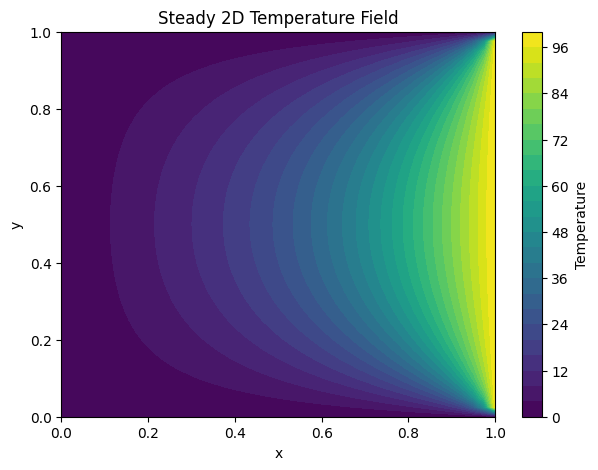

In [16]:
plt.figure(figsize=(7, 5))
plt.contourf(x, y, T, levels=25)
plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Steady 2D Temperature Field")
plt.show()

## Surface-style image plot

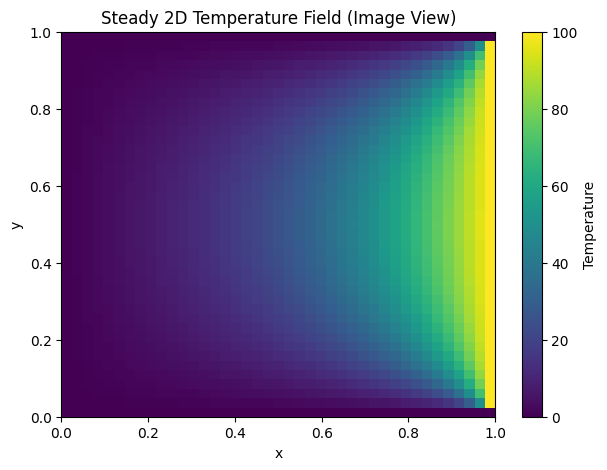

In [17]:
plt.figure(figsize=(7, 5))
plt.imshow(
    T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="auto"
)
plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Steady 2D Temperature Field (Image View)")
plt.show()

## Temperature at the center of the plate

In [18]:
ic = Nx // 2
jc = Ny // 2

print(f"x_center = {x[ic]:.3f}")
print(f"y_center = {y[jc]:.3f}")
print(f"T_center = {T[jc, ic]:.4f}")

x_center = 0.500
y_center = 0.500
T_center = 24.9998


## A quick look at several horizontal slices

This helps students see how the solution varies across the plate.

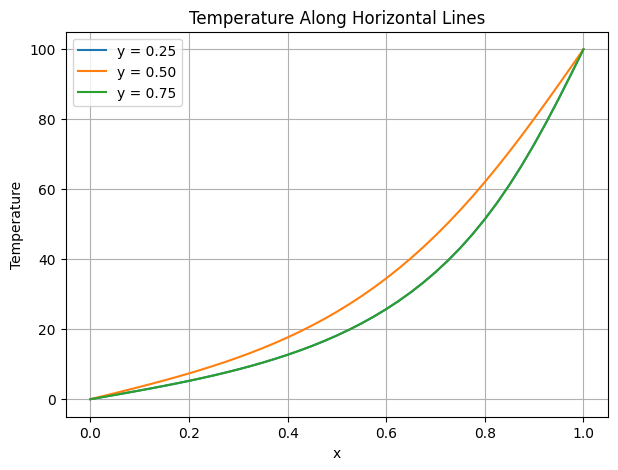

In [19]:
plt.figure(figsize=(7, 5))
for frac in [0.25, 0.50, 0.75]:
    j = int(frac * (Ny - 1))
    plt.plot(x, T[j, :], label=f"y = {y[j]:.2f}")

plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("Temperature Along Horizontal Lines")
plt.legend()
plt.grid(True)
plt.show()

## Discussion

A few observations:

- The solution is **smooth** in the interior.
- The hot right edge influences the entire plate.
- Temperatures bend toward the cold top and bottom edges.
- The discrete update only uses the four nearest neighbors, which is why this is called the **five-point stencil**.

This is a very natural place to transition into:
- larger sparse linear systems,
- iterative solvers,
- transient 2D heat conduction, or
- Neumann / Robin boundary conditions.

## Optional extension

Try changing the boundary conditions, for example:
- make the **top edge hot** instead of the right edge,
- set the left edge to **50**,
- or use a **rectangular plate** with `Lx != Ly`.

Then rerun the notebook and see how the temperature field changes.